In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


In [3]:
df=pd.read_csv(r"C:\Users\HI\Desktop\crypto\data\ETHUSDT_2h_from_1AM.csv")

In [4]:
df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol,ignore
0,2023-12-31 18:00:00,2298.34,2305.79,2290.80,2294.83,15951.0847,2023-12-31 19:59:59.999,3.663692e+07,38214,7801.8332,1.791737e+07,0
1,2023-12-31 20:00:00,2294.83,2294.83,2280.11,2283.20,20269.8327,2023-12-31 21:59:59.999,4.635346e+07,44856,10349.5507,2.366682e+07,0
2,2023-12-31 22:00:00,2283.21,2293.99,2258.88,2281.87,28662.5558,2023-12-31 23:59:59.999,6.529592e+07,67403,13089.8713,2.982511e+07,0
3,2024-01-01 00:00:00,2281.87,2306.60,2281.27,2303.72,19185.3443,2024-01-01 01:59:59.999,4.404984e+07,45166,10626.4057,2.439674e+07,0
4,2024-01-01 02:00:00,2303.72,2304.72,2271.00,2273.81,16553.9893,2024-01-01 03:59:59.999,3.786304e+07,41998,7194.6617,1.645186e+07,0


In [5]:
df = df.sort_values('open_time')

 # Giới thiệu về bộ dữ liệu 

open_time: thời gian bắt đầu nến  ( timestamp)

open : giá mở trong ngày  (eth/usd)

high: giá cao nhất (usd)

low: giá thấp nhất (usd)

close: giá đóng trong ngày (usd)

volumne: Khối lượng giao dịch (tính theo ETH)

close_time: thời gian kết thúc nến (timestamp)

quote_asset_volume: khối lượng giao dịch tính theo usdt

num_trades: số lượng giao dịch thực hiện (mua+bán) trong 2 giờ

taker_buy_base_vol : số lượng ETH mà người mua chủ động mua trong khoảng thời gian đó.

taker_buy_quote_vol	: số lượng USD mà người mua chủ động chi ra để mua ETH.

ignore : chưa rõ toàn số 0
 

In [6]:
# xem thông tin dữ liệu 
print('Overview about data')
df.info()

Overview about data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6792 entries, 0 to 6791
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   open_time            6792 non-null   object 
 1   open                 6792 non-null   float64
 2   high                 6792 non-null   float64
 3   low                  6792 non-null   float64
 4   close                6792 non-null   float64
 5   volume               6792 non-null   float64
 6   close_time           6792 non-null   object 
 7   quote_asset_volume   6792 non-null   float64
 8   num_trades           6792 non-null   int64  
 9   taker_buy_base_vol   6792 non-null   float64
 10  taker_buy_quote_vol  6792 non-null   float64
 11  ignore               6792 non-null   int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 636.9+ KB


In [7]:
# chuyển close_time sang định dạng datetime
df['close_time'] = pd.to_datetime(df['close_time'])
df['open_time'] = pd.to_datetime(df['open_time'])

In [8]:
# kiểm tra dữ liệu thiếu 
df.isnull().sum()

open_time              0
open                   0
high                   0
low                    0
close                  0
volume                 0
close_time             0
quote_asset_volume     0
num_trades             0
taker_buy_base_vol     0
taker_buy_quote_vol    0
ignore                 0
dtype: int64

In [9]:
#  thống kê dữ liệu 
print('statistic in data ')
numeric_cols=df.select_dtypes(include='number').columns
df[numeric_cols].describe()

statistic in data 


,open,high,low,close,volume,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol,ignore
count,6792.000000,6792.000000,6792.000000,6792.000000,6792.000000,6.792000e+03,6.792000e+03,6792.000000,6.792000e+03,6792.0
mean,2842.081090,2861.640920,2820.988750,2842.263591,39850.995069,1.118622e+08,2.013400e+05,19764.622136,5.551249e+07,0.0
std,591.753267,595.067085,588.035408,591.777981,40410.383136,1.111539e+08,1.935106e+05,19907.123629,5.487524e+07,0.0
min,1418.790000,1454.690000,1385.050000,1418.800000,3701.916200,9.847637e+06,1.444400e+04,1871.724900,4.532905e+06,0.0
25%,2451.047500,2467.577500,2434.560000,2451.355000,17439.509450,4.673997e+07,7.657125e+04,8551.432775,2.295656e+07,0.0
50%,2729.145000,2749.475000,2707.450000,2729.900000,27932.618750,7.767219e+07,1.347915e+05,13846.258500,3.862515e+07,0.0
75%,3341.002500,3364.125000,3316.850000,3341.085000,47869.808700,1.368685e+08,2.539118e+05,23990.090350,6.806546e+07,0.0
max,4067.610000,4107.800000,4049.120000,4067.620000,688621.024100,1.698076e+09,2.328632e+06,332787.533500,8.214258e+08,0.0


Nhận xét : 

nhìn vào biểu đồ này ta có thể thấy được 

cột open : Mean: ~2,842 → mức giá trung bình trong giai đoạn.,Min: ~1,418 (thấp nhất cuối 2023), Max: ~4,067 (cao nhất giữa 2025),Std: ~592 → biến động giá khá lớn, thể hiện thị trường dao động mạnh


cột high: Gần tương đồng với open, dao động ~1,454 → 4,107, Mean: ~2,861, chênh lệch với giá mở cửa nhỏ → không có nhiều ngày giá tăng đột biến cực lớn so với open

cột low: Min: ~1,385 → mức đáy của giai đoạn, Max: ~4,049 → vẫn gần sát max của high → phản ánh có những phiên biến động toàn bộ biên độ.


cột close: Mean: ~2,842 → tương đương giá mở cửa → xu hướng giá dài hạn tương đối cân bằng, Min: ~1,418, Max: ~4,067 → trùng gần min/max của open.


tương tự 

In [10]:
# xóa côt ignore
df.drop(columns=['ignore'], inplace=True)

In [11]:
# vì dữ liệu đang ở giờ quốc tế nên chuyển về giờ việt nam 
df['open_time'] = df['open_time'] + pd.Timedelta(hours=7)
df['close_time']= df['close_time']+ pd.Timedelta(hours=7)

In [12]:
df['hour'] = df['open_time'].dt.hour
df['weekday'] = df['open_time'].dt.weekday   # 0 = Monday, 6 = Sunday
df['month'] = df['open_time'].dt.month
df['year'] = df['open_time'].dt.year

In [13]:
df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol,hour,weekday,month,year
0,2024-01-01 01:00:00,2298.34,2305.79,2290.80,2294.83,15951.0847,2024-01-01 02:59:59.999,3.663692e+07,38214,7801.8332,1.791737e+07,1,0,1,2024
1,2024-01-01 03:00:00,2294.83,2294.83,2280.11,2283.20,20269.8327,2024-01-01 04:59:59.999,4.635346e+07,44856,10349.5507,2.366682e+07,3,0,1,2024
2,2024-01-01 05:00:00,2283.21,2293.99,2258.88,2281.87,28662.5558,2024-01-01 06:59:59.999,6.529592e+07,67403,13089.8713,2.982511e+07,5,0,1,2024
3,2024-01-01 07:00:00,2281.87,2306.60,2281.27,2303.72,19185.3443,2024-01-01 08:59:59.999,4.404984e+07,45166,10626.4057,2.439674e+07,7,0,1,2024
4,2024-01-01 09:00:00,2303.72,2304.72,2271.00,2273.81,16553.9893,2024-01-01 10:59:59.999,3.786304e+07,41998,7194.6617,1.645186e+07,9,0,1,2024


In [14]:
# kiểm tra cột year
df['year'].unique()

array([2024, 2025], dtype=int32)

In [15]:
# kiểm ngày trong tuần 
df['weekday'].unique()

array([0, 1, 2, 3, 4, 5, 6], dtype=int32)

In [16]:
#kiểm tra tháng 
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [17]:
#kiểm tra giờ 
df['hour'].unique()

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23], dtype=int32)

feature engineering 

In [18]:
# phần trăm thay đổi giá so với nến trước 
df['price_change_pct'] = (df['close'] - df['open']) / df['open'] * 100

In [19]:
# tính sự chênh lệch giá đóng cửa hiện tại so với giá đóng cửa của 5 nến trước 
df['momentum_5'] = df['close'] - df['close'].shift(5)

nếu chênh lệnh > 0 thì giá hiện tại cao hơn nhiều so với 5 phiên trước, gần 0 thì giá chỉ tăng nhẹ so với 5 phiên trước, =0 thì giá hiện tại bằng giá 5 phiên trước ,..

In [20]:
#  tỉ lệ người mua chủ động trong tổng khối lượng giao dịch tính theo giá trị quote asset 
df['taker_buy_ratio'] = df['taker_buy_quote_vol'] / df['quote_asset_volume']

Nếu tỷ lệ này cao, nghĩa là nhiều người mua chủ động => thị trường có xu hướng tăng.

Nếu thấp, có thể thị trường đang chịu áp lực bán nhiều hơn

In [21]:
# 3. Rolling statistics 
df['rolling_mean_5'] = df['close'].rolling(window=5).mean()
df['rolling_std_5'] = df['close'].rolling(window=5).std()

rolling_mean_5 : là giá trung bình đóng của 5 nến gần nhất kể cả nến hiện tại 

Nếu giá hiện tại > rolling_mean_5 ⇒ giá đang cao hơn mức trung bình gần đây → xu hướng có thể tăng.

Nếu giá hiện tại < rolling_mean_5 ⇒ giá đang thấp hơn mức trung bình gần đây → xu hướng có thể giảm

còn rolling_std_5 : là độ biến động của giá đóng trong 5 nến gần nhất , nếu độ bd lớn thì thị trường sôi động còn ngược lại thì ít biến động

In [22]:
# 5. RSI (Relative Strength Index)
delta = df['close'].diff()
gain = delta.clip(lower=0)# giá trị nhỏ hơn 0 thì gán = 0 
loss = -delta.clip(upper=0)# chỉ giữ mức giảm giá dưới dạng số dương., giá trị lớn hơn 0 gán = 0 

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))

rsi(Relative Strength Index ) là chỉ báo động lượng dùng để đo dùng để đo tốc độ và mức thay đổi của giá để xác định thị trường đang quá mua (overbought) hay quá bán (oversold)

Nó đo lực mua so với lực bán:

RSI = 100 → 14 phiên toàn tăng, mua áp đảo tuyệt đối.

RSI = 0 → 14 phiên toàn giảm, bán áp đảo tuyệt đối.

RSI = 50 → mua ≈ bán, thị trường cân bằng.

Quá mua: Giá tăng quá nhanh, bên mua “mệt” → dễ giảm ( rsi > 70 )

quá bán: Giá giảm quá nhanh, bên bán “mệt” → dễ tăng (rsi < 30 )

In [23]:
df.isnull().sum()

open_time               0
open                    0
high                    0
low                     0
close                   0
volume                  0
close_time              0
quote_asset_volume      0
num_trades              0
taker_buy_base_vol      0
taker_buy_quote_vol     0
hour                    0
weekday                 0
month                   0
year                    0
price_change_pct        0
momentum_5              5
taker_buy_ratio         0
rolling_mean_5          4
rolling_std_5           4
rsi_14                 14
dtype: int64

In [24]:
# xóa những cột nan do tạo đặc trưng tạo ra 
df.dropna(inplace=True)

In [25]:
df.isnull().sum()

open_time              0
open                   0
high                   0
low                    0
close                  0
volume                 0
close_time             0
quote_asset_volume     0
num_trades             0
taker_buy_base_vol     0
taker_buy_quote_vol    0
hour                   0
weekday                0
month                  0
year                   0
price_change_pct       0
momentum_5             0
taker_buy_ratio        0
rolling_mean_5         0
rolling_std_5          0
rsi_14                 0
dtype: int64

In [26]:
# tạo biến mục tiêu 
df['label'] = df.apply(lambda x: 1 if x['price_change_pct'] > 0 else 0, axis=1)

In [27]:
df['label'].value_counts()

label
1    3520
0    3258
Name: count, dtype: int64

In [ ]:
# lưu dataset
df.to_csv('ethereum.csv',index=True)

# Trực quan hóa dữ liệu 

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [28]:
#1 Biểu đồ đường giá đóng cửa theo thời gian
fig1 = px.line(df, x='open_time', y='close', 
               labels={'close':'Giá đóng cửa', 'open_time':'Thời gian'},
               title='Biểu đồ đường giá đóng cửa ETH')
fig1.show()

qua biểu đồ này ta có thấy được giá của đồng ethereum biến động rất mạnh có thể tăng tới 4067 usd trong tháng 12 năm 2024 và sau vài tháng , tới tháng 4 năm 2025 giá giảm tận đáy chạm mốc 1418 usd , đây là loại tài sản có rủi ro cao có thể thu đc lợi nhuận cao củng có thể thua lỗ, tính tới thời điểm tháng 7 năm 2025 thì giá của eth có đà tăng lại 

In [30]:
gia_dong_cua_Tb= df['close'].mean()
print(f"Giá đóng cửa trung bình: {gia_dong_cua_Tb}")

Giá đóng cửa trung bình: 2843.3821687813515


In [31]:
gia_dong_cua_max= df['close'].max()
print(f"Giá đóng cửa cao nhất: {gia_dong_cua_max}")
gia_dong_cua_min= df['close'].min()
print(f"Giá đóng cửa thấp nhất: {gia_dong_cua_min}")

Giá đóng cửa cao nhất: 4067.62
Giá đóng cửa thấp nhất: 1418.8


In [32]:
#2 Biểu đồ phân phối biến đổi phần trăm giá đóng cửa
fig2 = px.histogram(df, x='price_change_pct', nbins=50, 
                    labels={'price_change_pct':'Biến đổi phần trăm giá đóng cửa'},
                    title='Phân phối biến đổi phần trăm giá đóng cửa ETH')
fig2.show()

nhìn vào biểu đồ có thể thấy được là tỷ lệ thay đổi của giá nó không quá lớn tập trung trong khoảng tăng 5% và giảm 5% nhưng đa số vẫn là khoảng 1% - 2% và ta thấy được xu hướng giá tăng hơn giá giảm 1 xíu và nó củng cho ta biết 1 thông tin là những giá cao vượt bậc hay giảm chạm đáy là những thời điểm mà giá biến động mạnh 

   label        volume
0      0  41164.836121
1      1  38718.635762


C:\Users\HI\AppData\Local\Temp\ipykernel_17620\2246376535.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




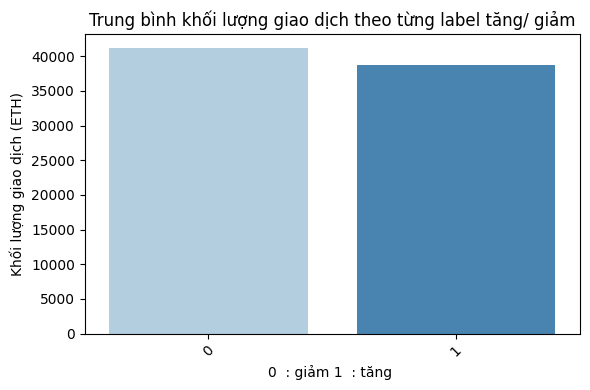

In [33]:

label_volume = df.groupby('label')['volume'].mean().reset_index()

print(label_volume)

plt.figure(figsize=(6, 4))
sns.barplot(x='label', y='volume', data=label_volume, palette='Blues')
plt.title("Trung bình khối lượng giao dịch theo từng label tăng/ giảm")
plt.xlabel("0  : giảm 1  : tăng ")
plt.ylabel("Khối lượng giao dịch (ETH)")

# 4. Xoay nhãn trục x để dễ đọc
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


qua biểu đồ này thì thấy tổng số eth được giao dịch trung bình tring 2 giờ  khi mà giá của đồng eth giảm nhiều hơn tổng số eth được giao dịch giao dịch khi đồng eth tăng, sẽ có 2 th xảy ra:

- người đang giữ eth sẽ lo sợ giá sẽ giảm nửa nên bán để cắt lỗ

- còn người lại 1 số người sẽ xem đây là cơ hội vàng để bắt đáy, mua với giá trẻ và kì vọng giá sẽ tăng 

C:\Users\HI\AppData\Local\Temp\ipykernel_2004\3270437515.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




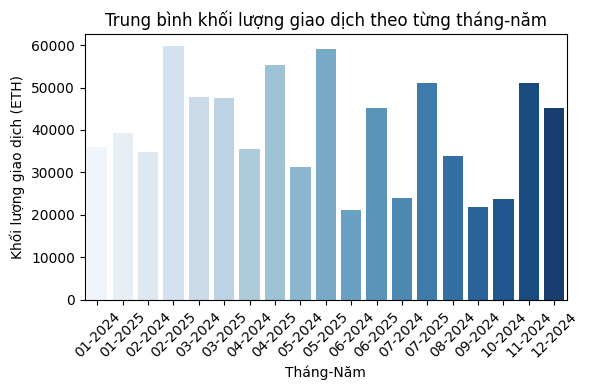

In [30]:
df['month_year'] = df['open_time'].dt.strftime('%m-%Y')
monthly_volume = df.groupby('month_year')['volume'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='month_year', y='volume', data=monthly_volume, palette='Blues')
plt.title("Trung bình khối lượng giao dịch theo từng tháng-năm")
plt.xlabel("Tháng-Năm")
plt.ylabel("Khối lượng giao dịch (ETH)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


so sánh với biểu đồ giá đóng của theo thời gian thì ở thời điểm tháng 2/2025 và tháng 5/2025 là hai thời điểm mà giá bắt đầu tăng lại sau thời điểm mà giá giảm bắt đáy , trong biểu đồ này hai thời điểm có khối lượng giao dịch nhiều nhất cho thấy là sau thời điểm giá giảm chạm đáy thì giá bắt đầu có xu hướng tăng lại nên khá nhiều giao dịch trong thời đỉm này 

C:\Users\HI\AppData\Local\Temp\ipykernel_2004\134199075.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




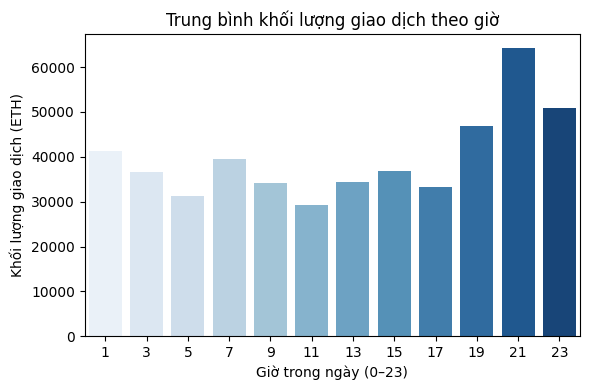

In [31]:
#5 Tính khối lượng trung bình theo giờ
hourly_volume = df.groupby('hour')['volume'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(x='hour', y='volume', data=hourly_volume, palette='Blues')

plt.title("Trung bình khối lượng giao dịch theo giờ")
plt.xlabel("Giờ trong ngày (0–23)")
plt.ylabel("Khối lượng giao dịch (ETH)")
plt.tight_layout()
plt.show()


khung giờ 21h-23h ở việt nam chính là thời điểm mà thị trường châu âu đang làm việc buổi chiều và thị trường mỹ bắt đầu giao dịch mới buổi sáng,sự "giao thoa" này khiến cả ba thị trường lớn (Á, Âu, Mỹ) cùng lúc hoạt động, tạo ra thanh khoản và khối lượng giao dịch cao nhất trong ngày, cho nên thời đỉm ban đêm là thời điểm tốt để giao dịch 

C:\Users\HI\AppData\Local\Temp\ipykernel_2004\857520322.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




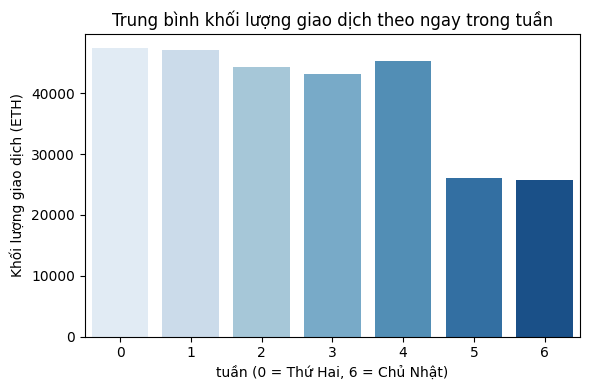

In [32]:

#6  Tính khối lượng trung bình giao dịch những ngày trong tuần 
week_volume = df.groupby('weekday')['volume'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(x='weekday', y='volume', data=week_volume, palette='Blues')

plt.title("Trung bình khối lượng giao dịch theo ngay trong tuần")
plt.xlabel("tuần (0 = Thứ Hai, 6 = Chủ Nhật)")
plt.ylabel("Khối lượng giao dịch (ETH)")
plt.tight_layout()
plt.show()


khối lượng giao dịch từ thứ 2 tới thứ 6 đều cao chỉ có thứ 7 chủ nhật thì khối lượng giảm , thì có thể thấy là mặc dụ thi trường tiền kĩ thuật số nó hoạt độgn 24/7 nhưng nó vẫn bi chi phối bởi thị trường tài chính truyền thống , Các tổ chức lớn, quỹ đầu tư, và các nhà giao dịch chuyên nghiệp chủ yếu làm việc từ thứ Hai đến thứ Sáu. Khi họ nghỉ ngơi vào cuối tuần, một phần lớn thanh khoản và hoạt động giao dịch bị rút khỏi thị trường, dẫn đến sự sụt giảm mạnh về volume

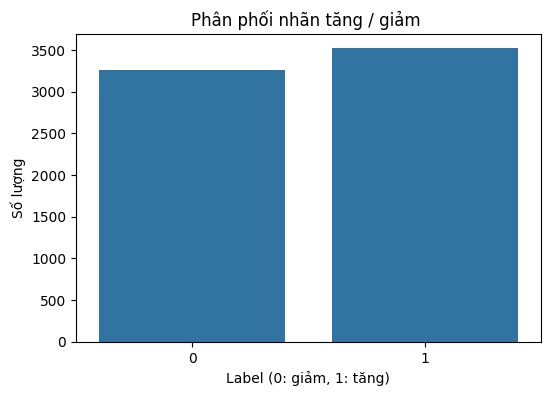

In [37]:
#11  Phân phối tăng/giảm giá (label)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Phân phối nhãn tăng / giảm ')
plt.xlabel("Label (0: giảm, 1: tăng)")
plt.ylabel("Số lượng")
plt.show()

số nhãn tăng nhiều hơn nhãn giảm trong bộ dữ liệu này nhưng không có xảy ra mất cân bằng nhãn

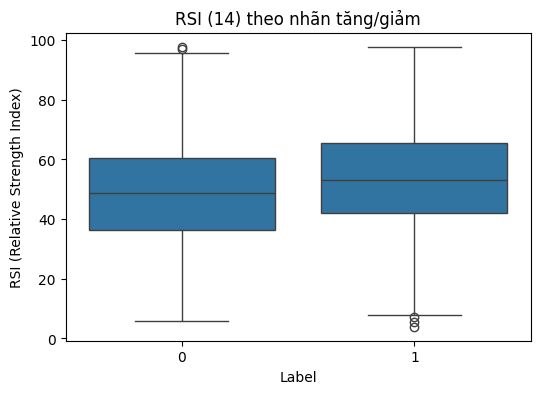

In [33]:
# 12 RSI theo xu hướng giá
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='rsi_14', data=df)
plt.title("RSI (14) theo nhãn tăng/giảm")
plt.xlabel("Label")
plt.ylabel("RSI (Relative Strength Index)")
plt.show()

nhìn vào biểu đồ ta thấy hộp phải khi rsi ở mức cao hơn thì khả năng giá tăng vào ngày hôm sau , ngược lại thì khả năng giá giảm lơn hơn , và  ta thấy có giá trị ngoại lai trên hộp 0 , rsi đang ở mức gần 100, nhưng kết quả là giá hôm sau sẽ giảm có thể là cái bẫy và ngược lại với hộp 1 

| Quan sát                                | Ý nghĩa                                                |
| --------------------------------------- | ------------------------------------------------------ |
| RSI cao thường đi kèm giá tăng hôm sau  | RSI là chỉ báo tốt cho **xu hướng tăng** ngắn hạn.     |
| RSI thấp thường đi kèm giá giảm hôm sau | RSI phản ánh lực bán → giá dễ giảm.                    |
| RSI rất cao nhưng giá vẫn giảm          | **Bẫy quá mua** → cảnh báo về khả năng đảo chiều giảm. |
| RSI rất thấp nhưng giá vẫn tăng         | **Bẫy quá bán** → khả năng đảo chiều tăng.             |


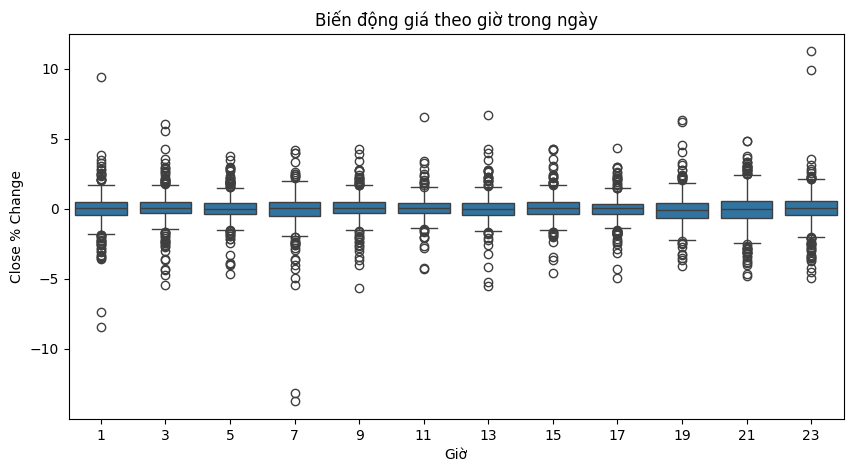

In [35]:
# 13 Biến động giá theo giờ (Intraday pattern)
plt.figure(figsize=(10, 5))
sns.boxplot(x='hour', y='price_change_pct', data=df)
plt.title("Biến động giá theo giờ trong ngày")
plt.xlabel("Giờ")
plt.ylabel("Close % Change")
plt.xticks(rotation=0)
plt.show()

khi nhìn đường trung bình , giá trị nằm sát mốc 0% , có nghĩa là tại bất kì giờ nào, khả năng giá tăng hay giảm đều gần 50/50 , không thể dựa vào giờ giao dịch để đoán hướng đi của giá.

C:\Users\HI\AppData\Local\Temp\ipykernel_2004\1901486072.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




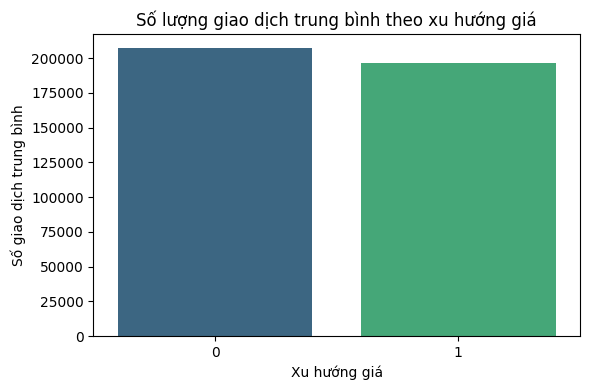

In [36]:
# 14 Num Trades theo xu hướng giá
trade_stats = df.groupby('label')['num_trades'].mean().reset_index()

# Vẽ biểu đồ cột
plt.figure(figsize=(6, 4))
sns.barplot(x='label', y='num_trades', data=trade_stats, palette='viridis')

plt.title("Số lượng giao dịch trung bình theo xu hướng giá")
plt.xlabel("Xu hướng giá")
plt.ylabel("Số giao dịch trung bình")
plt.tight_layout()
plt.show()

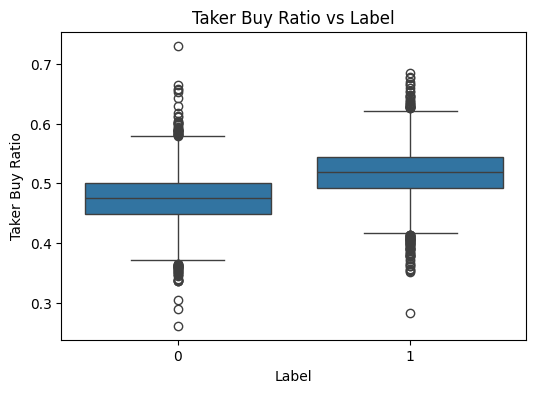

In [37]:
# 15 Taker Buy Ratio theo nhãn giá
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='taker_buy_ratio', data=df)
plt.title("Taker Buy Ratio vs Label")
plt.xlabel("Label")
plt.ylabel("Taker Buy Ratio")
plt.show()


Taker Buy Ratio có thể là chỉ báo hỗ trợ dự đoán giá tăng/giảm:

TBR cao hơn trung bình → giá dễ tăng.

TBR thấp hơn trung bình → giá dễ giảm

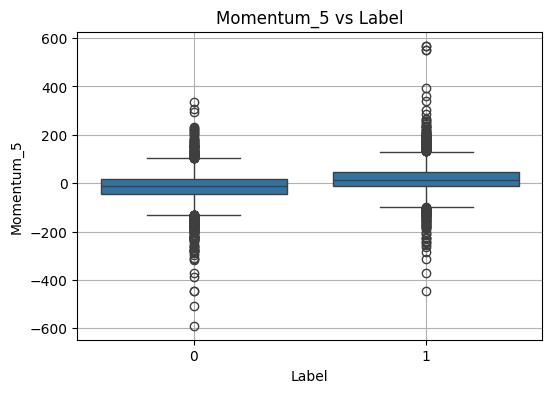

In [38]:
# biểu đồ thể hiện momentum_5
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='momentum_5', data=df)
plt.title('Momentum_5 vs Label')
plt.xlabel('Label')
plt.ylabel('Momentum_5')
plt.grid(True)
plt.show()

ta có thể thấy label 0 có median < 0 , momentum âm khả năng giá có xu hướng giảm 

ở label 1 có median dương , momentum dương có khả năng giá sẽ tăng, và ta thấy có nhiều outliers ngoài hai box tăng giảm có thể hiện giá cao vượt mức v à giá giảm chạm đáy 


In [39]:
def outlier_ratio(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    ratio = len(outliers) / len(series)
    return ratio * 100  

for col in ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
            'num_trades', 'taker_buy_base_vol', 'taker_buy_quote_vol', 
            'price_change_pct', 'momentum_5', 'taker_buy_ratio', 
            'rolling_mean_5', 'rolling_std_5', 'rsi_14']:
    ratio = outlier_ratio(df[col])
    print(f"{col}: {ratio:.2f}% outliers")


open: 0.00% outliers
high: 0.00% outliers
low: 0.00% outliers
close: 0.00% outliers
volume: 6.95% outliers
quote_asset_volume: 6.61% outliers
num_trades: 6.65% outliers
taker_buy_base_vol: 6.83% outliers
taker_buy_quote_vol: 6.52% outliers
price_change_pct: 7.14% outliers
momentum_5: 7.10% outliers
taker_buy_ratio: 1.22% outliers
rolling_mean_5: 0.00% outliers
rolling_std_5: 5.41% outliers
rsi_14: 0.00% outliers


In [40]:
# cắt ngưỡng outliers
def clip_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)
# Danh sách cột cần clipping
columns_to_clip = ['volume', 'quote_asset_volume', 'num_trades',
                   'taker_buy_base_vol', 'taker_buy_quote_vol',
                   'price_change_pct', 'momentum_5', 'taker_buy_ratio',
                   'rolling_std_5']

# Clipping và ghi đè vào dataframe
for col in columns_to_clip:
    df[col] = clip_outliers_iqr(df[col])


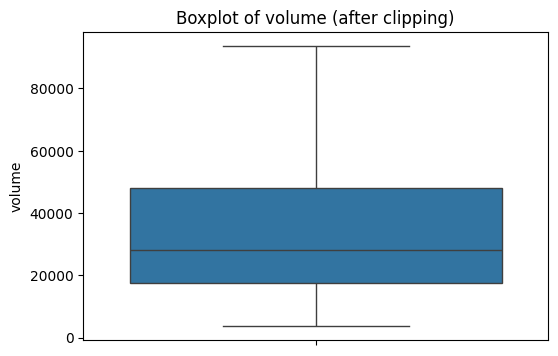

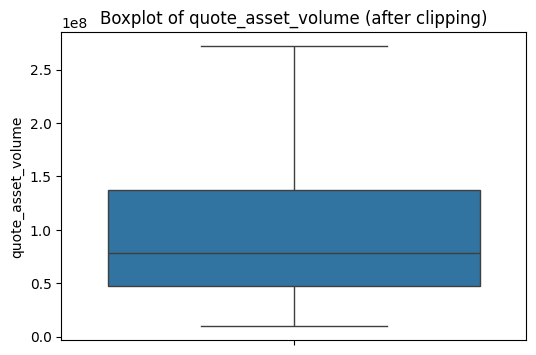

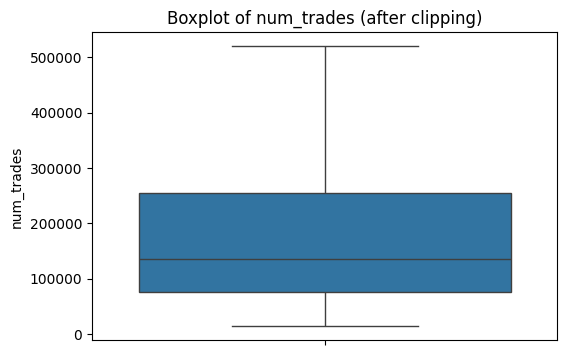

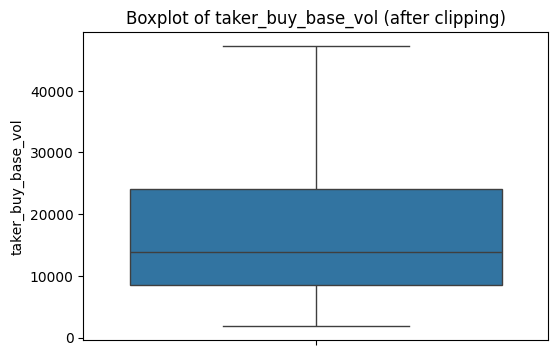

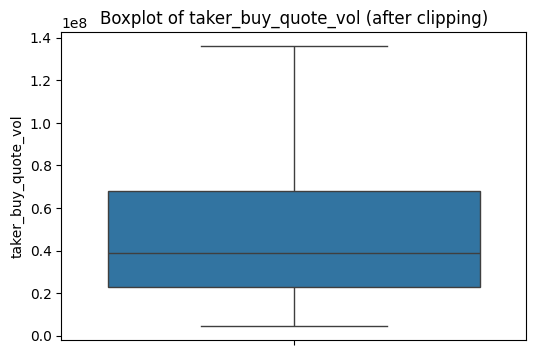

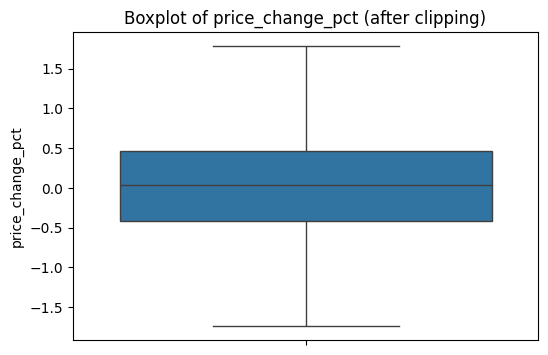

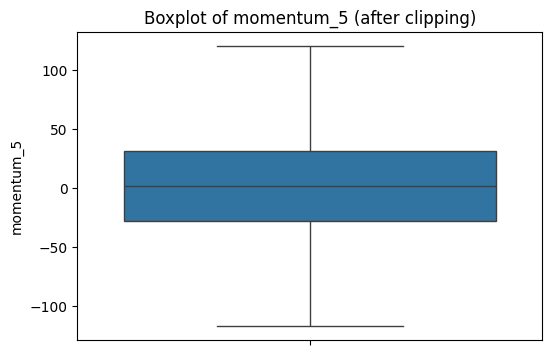

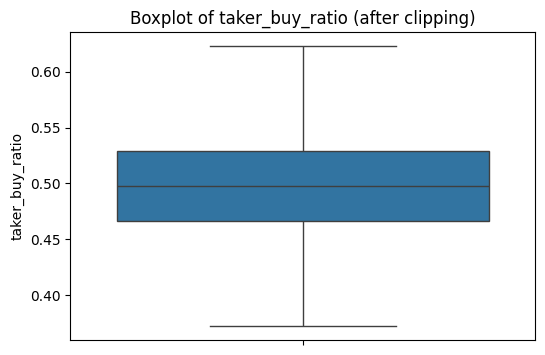

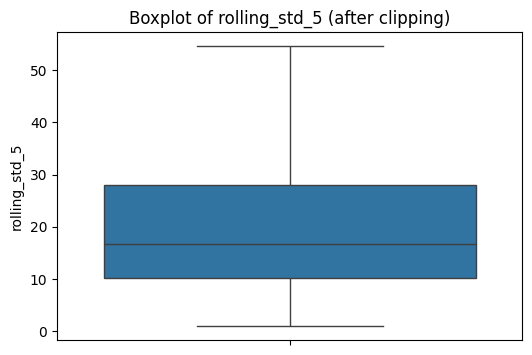

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in col_outlier:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col]) 
    plt.title(f'Boxplot of {col} (after clipping)')
    plt.ylabel(col)
    plt.show()



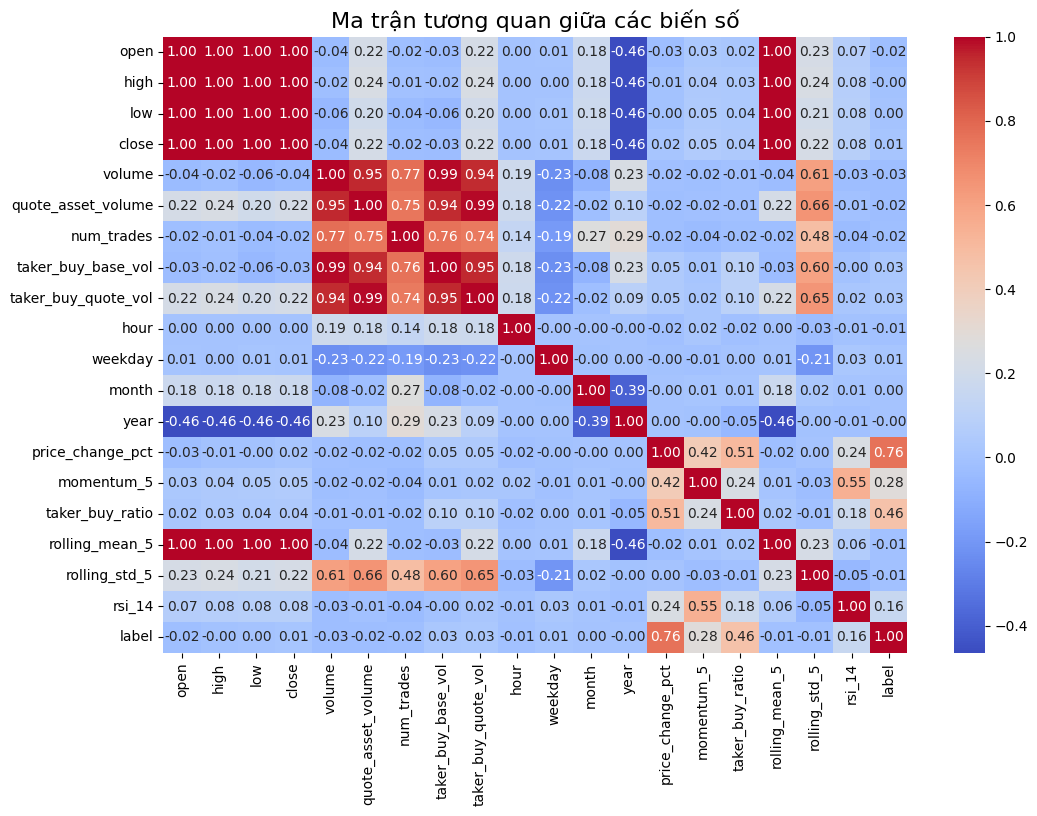

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,  
    annot=True,          
    fmt=".2f",           # Định dạng số thập phân 
    cmap='coolwarm',     # Màu
    cbar=True            # Thanh màu
)
plt.title("Ma trận tương quan giữa các biến số", fontsize=16)
plt.show()


những biến open, high, low, close tương quan xấp xỉ 1, để giảm đa công tuyến thì chỉ giữ lại 1 (close)

những biến volume, quote_asset_volume, take_buy_base_vol, take_buy_quote_vol tương quan > 0,95 chỉ cần 1 biến đại diện 

biến price_change_pct có tương quan mạnh nhất với label (0,76)

biến momentum_5, rsi_14, taker_buy_ratio củng có tương quan với label nhưng thấp

Các biến open, volume, hour, weekday, month, year → tương quan gần 0 với label → ít ảnh hưởng.

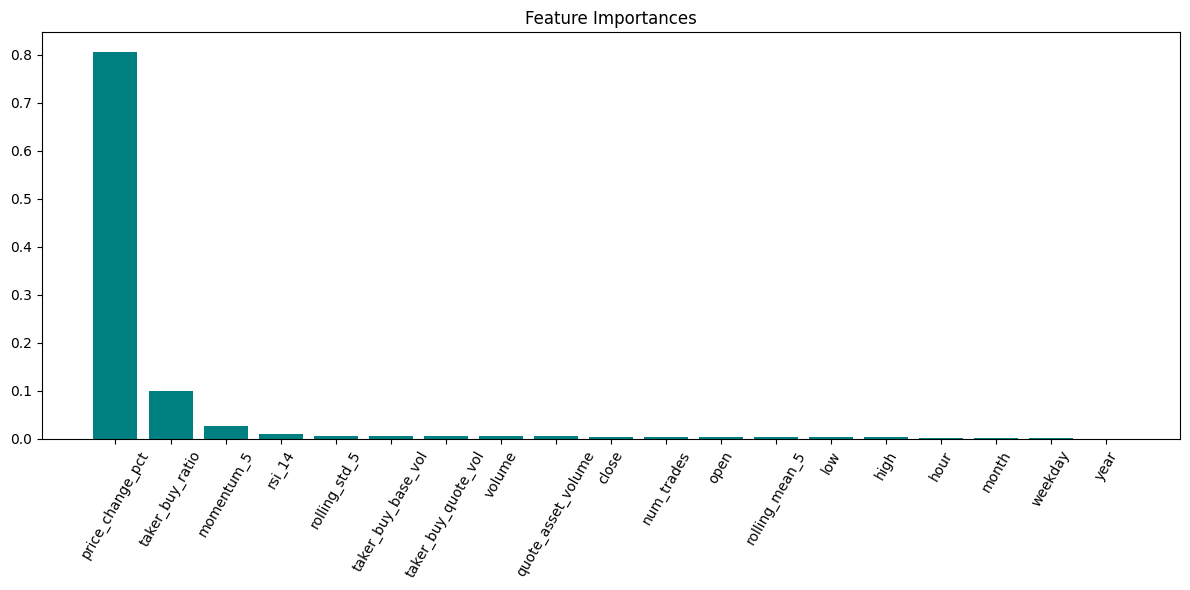

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chuẩn bị dữ liệu
feature_cols = [col for col in df.columns if col not in ['open_time', 'close_time', 'label','month_year']]
X = df[feature_cols]
y = df['label']

# Huấn luyện model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

# Lấy độ quan trọng của đặc trưng
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center', color='teal')
plt.xticks(range(len(importances)), feature_names[indices], rotation=60)
plt.tight_layout()
plt.show()

dựa vào biểu đồ tương quan và biểu đồ độ tin cậy của các biến có thể thấy biến price_change_pct là biến có nhiều ảnh hưởng nhất với label, vì label được tạo dựa vào cột price_change_pct , nếu đưa cột price_change_pct vào thì khả năng sẽ bị rò rỉ dữ liệu 

# chuẩn bị dl và xây dựng mô hình 

In [46]:
selected_features = [
    'close',
    'open',
    'quote_asset_volume',
    'volume',
    'num_trades',
    'momentum_5',
    'taker_buy_ratio',
    'rolling_std_5',
    'rsi_14'
]
X = df[selected_features]
y = df['label'] 

In [47]:
# 1. Chia train/test 
train_size = int(len(df) * 0.8)
X = df[selected_features]
y = df['label']
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [48]:
X_train.shape

(5422, 9)

In [49]:
X_train.head()

,close,open,quote_asset_volume,volume,num_trades,momentum_5,taker_buy_ratio,rolling_std_5,rsi_14
14,2352.04,2337.83,4.274265e+07,18261.6254,46869,47.88,0.562860,16.517839,69.666552
15,2378.08,2352.05,1.666173e+08,70111.8883,147674,63.38,0.495268,23.578751,79.675966
16,2386.43,2378.09,7.032090e+07,29554.6121,62040,72.67,0.471859,22.822311,81.327900
17,2377.48,2386.42,6.433613e+07,26976.6478,55109,40.22,0.518053,20.511218,73.951162
18,2385.84,2377.47,5.609460e+07,23565.0108,53477,48.01,0.480877,14.019678,92.297818


In [50]:
y_train.head()

14    1
15    1
16    1
17    0
18    1
Name: label, dtype: int64

In [51]:
X_test.shape


(1356, 9)

Accuracy: 0.7971976401179941
              precision    recall  f1-score   support

           0       0.82      0.74      0.77       641
           1       0.78      0.85      0.82       715

    accuracy                           0.80      1356
   macro avg       0.80      0.79      0.80      1356
weighted avg       0.80      0.80      0.80      1356



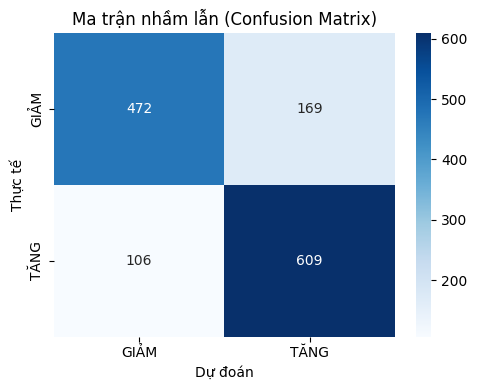

In [52]:


#  Scale 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

#  Predict + Đánh giá
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['GIẢM', 'TĂNG'], yticklabels=['GIẢM', 'TĂNG'])
plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.tight_layout()
plt.show()


In [53]:
import pandas as pd
import numpy as np

# Cố định seed để kết quả giống nhau mỗi lần chạy
np.random.seed(42)
n_samples = 1000  # số dòng dữ liệu giả

# Tạo dữ liệu giả
data_fake = {
    'close': np.random.uniform(1800, 2200, n_samples),
    'open': np.random.uniform(1800, 2200, n_samples),
    'volume': np.random.uniform(1000, 100000, n_samples),
    'num_trades': np.random.randint(100, 10000, n_samples),
    'momentum_5': np.random.uniform(-50, 50, n_samples),
    'taker_buy_ratio': np.random.uniform(0, 1, n_samples),
    'rolling_std_5': np.random.uniform(0, 100, n_samples),
    'rsi_14': np.random.uniform(10, 90, n_samples)
}

# Chuyển thành DataFrame
df_test_fake = pd.DataFrame(data_fake)

df_test_fake['quote_asset_volume'] = df_test_fake['close'] * df_test_fake['volume']

# Hiển thị 5 dòng đầu tiên
print(df_test_fake.head())


         close         open        volume  num_trades  momentum_5  \
0  1949.816048  1874.053172  26908.862690         982   -7.923880   
1  2180.285723  2016.760379  25450.901108        4508   10.168216   
2  2092.797577  2149.178334  90719.203472        4168   43.710894   
3  2039.463394  2092.889955  25705.073785        3377  -18.819786   
4  1862.407456  2122.624459  27923.022887        8666  -25.022784   

   taker_buy_ratio  rolling_std_5     rsi_14  quote_asset_volume  
0         0.209898      91.021665  56.848333        5.246733e+07  
1         0.260919      15.441576  57.308136        5.549024e+07  
2         0.969616      62.677052  67.535976        1.898569e+08  
3         0.734709       2.880118  69.619319        5.242456e+07  
4         0.699597      64.371981  51.156195        5.200405e+07  


In [61]:
df_test_fake.shape

(1000, 10)

In [63]:
df_test_fake.sum().isnull()

close                 False
open                  False
volume                False
num_trades            False
momentum_5            False
taker_buy_ratio       False
rolling_std_5         False
rsi_14                False
quote_asset_volume    False
label                 False
dtype: bool

In [54]:
# Label: 1 nếu tăng giá (pct > 0), ngược lại 0
df_test_fake['label'] = (df_test_fake['close'] > df_test_fake['open']).astype(int)


In [55]:
df_test_fake.head()

,close,open,volume,num_trades,momentum_5,taker_buy_ratio,rolling_std_5,rsi_14,quote_asset_volume,label
0,1949.816048,1874.053172,26908.862690,982,-7.923880,0.209898,91.021665,56.848333,5.246733e+07,1
1,2180.285723,2016.760379,25450.901108,4508,10.168216,0.260919,15.441576,57.308136,5.549024e+07,1
2,2092.797577,2149.178334,90719.203472,4168,43.710894,0.969616,62.677052,67.535976,1.898569e+08,0
3,2039.463394,2092.889955,25705.073785,3377,-18.819786,0.734709,2.880118,69.619319,5.242456e+07,0
4,1862.407456,2122.624459,27923.022887,8666,-25.022784,0.699597,64.371981,51.156195,5.200405e+07,0


In [56]:
X_fake = df_test_fake[selected_features] 
X_fake_scaled = scaler.transform(X_fake)


In [57]:
y_fake = df_test_fake['label']

In [58]:
# Dự đoán nhãn và xác suất
prediction = model.predict(X_fake_scaled)
proba = model.predict_proba(X_fake_scaled)


Accuracy: 0.735

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       500
           1       0.74      0.72      0.73       500

    accuracy                           0.73      1000
   macro avg       0.74      0.73      0.73      1000
weighted avg       0.74      0.73      0.73      1000


Confusion Matrix:
[[375 125]
 [140 360]]


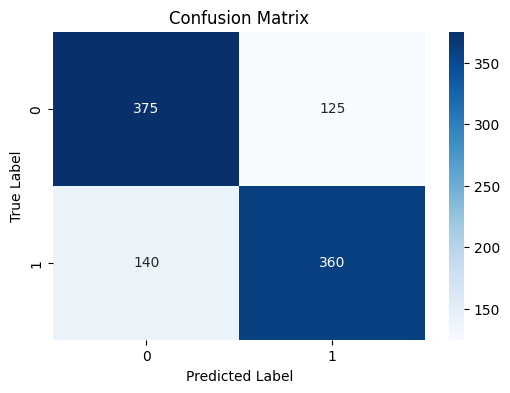


ROC AUC Score: 0.8329


In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Độ chính xác
print("Accuracy:", accuracy_score(y_fake, prediction))

# Precision, Recall, F1
print("\nClassification Report:")
print(classification_report(y_fake, prediction))

# Ma trận nhầm lẫn
print("\nConfusion Matrix:")
print(confusion_matrix(y_fake, prediction))

# Tính ma trận nhầm lẫn
cm = confusion_matrix(y_fake, prediction)

# Vẽ heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ROC AUC 
roc_auc = roc_auc_score(y_fake, proba[:, 1])
print(f"\nROC AUC Score: {roc_auc:.4f}")



In [ ]:

df_result_fake = df_test_fake.copy()
df_result_fake['predict'] = prediction
df_result_fake['Xác suất giảm (%)'] = (proba[:, 0] * 100).round(2)
df_result_fake['Xác suất tăng (%)'] = (proba[:, 1] * 100).round(2)
print(df_result_fake[['close', 'open','label','predict', 'Xác suất giảm (%)', 'Xác suất tăng (%)']].head(10))


         close         open  label  predict  Xác suất giảm (%)  \
0  1949.816048  1874.053172      1        0              93.37   
1  2180.285723  2016.760379      1        1              25.49   
2  2092.797577  2149.178334      0        1               0.10   
3  2039.463394  2092.889955      0        1               7.01   
4  1862.407456  2122.624459      0        0              98.93   
5  1862.397808  2063.513347      0        1              46.33   
6  1823.233445  2076.910626      0        0             100.00   
7  2146.470458  2139.678261      1        1               1.95   
8  2040.446005  1899.867204      1        1               0.62   
9  2083.229031  1995.769985      1        1               0.01   

   Xác suất tăng (%)  
0               6.63  
1              74.51  
2              99.90  
3              92.99  
4               1.07  
5              53.67  
6               0.00  
7              98.05  
8              99.38  
9              99.99  


In [ ]:
y_train_pred = model.predict(X_train_scaled)

# Đánh giá độ chính xác
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on Train:", accuracy_score(y_train, y_train_pred))
print("Classification Report on Train:\n", classification_report(y_train, y_train_pred))


Accuracy on Train: 0.83364072298045
Classification Report on Train:
               precision    recall  f1-score   support

           0       0.84      0.81      0.83      2617
           1       0.83      0.85      0.84      2805

    accuracy                           0.83      5422
   macro avg       0.83      0.83      0.83      5422
weighted avg       0.83      0.83      0.83      5422

